# Acoblament no-mínim — Model CPL
## $G_\mathrm{eff}(z)/G_N$ per a **dues tries de $\rho_\Lambda$**

Model escalar–tensor (frame de Jordan, terme cinètic canònic, potencial constant $U(\phi)=\rho_\Lambda$) amb història d'expansió CPL $w_{DE}(z)=w_0+w_a\,z/(1+z)$.


- **mateix color** = mateix cas (A o B),
- **línia sòlida** = primera tria de $\rho_\Lambda$,
- **línia discontínua** = segona tria de $\rho_\Lambda$.

## 1. Paràmetres i constants

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize  import curve_fit
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

# ── Unitats naturals: H0 = G = 1 ─────────────────────────────────────────────
G       = 1.0
H0      = 1.0
Omega_m = 0.3

# ── Constants derivades ───────────────────────────────────────────────────────
rho_c  = 3*H0**2 / (8*np.pi*G)
F0     = 1.0 / (16*np.pi*G)        # F(z=0) = 1/(16piG)
rho_m0 = Omega_m * rho_c

# ── Les DUES tries de rho_Lambda a comparar ──────────────────────────────────
#   - tria 1 (sòlida): 0.6999*rho_c       
#   - tria 2 (discontínua): (1-Omega_m)*rho_c → pressupost cosmològic; força phi'(1)=0
# L'ORDRE del diccionari fixa l'estil: 1a tria → línia sòlida, 2a → discontínua.
rho_Lambda_choices = {
    r'$\rho_\Lambda=0.6999\,\rho_c$':     0.696 * rho_c,
    r'$\rho_\Lambda=(1-\Omega_m)\rho_c$':  0.6999 * rho_c,
}

# ── Els dos casos CPL ─────────────────
cases = {
    'A': dict(w0=-0.96, wa=-0.04, label=r'Cas A: $w_0{+}w_a={-}1$',  color='steelblue'),
    'B': dict(w0=-0.80, wa=-0.80, label=r'Cas B: DESI best-fit',     color='darkred'),
}

# ── Interval d'integració ────────────────────────────────────────────────────
z_min, z_max = 0.0, 2.0
a_max, a_min = 1.0/(1+z_min), 1.0/(1+z_max)   # [1/3, 1]
N_pts        = 4000
a_eval       = np.linspace(a_max, a_min, N_pts)

print("Paràmetres:")
print(f"  Omega_m  = {Omega_m}")
print(f"  rho_c    = {rho_c:.6f}")
print(f"  F0       = {F0:.8f}  [= 1/(16piG)]")
print(f"  rho_m0   = {rho_m0:.6f}")
print(f"  Rang z   = [{z_min}, {z_max}]")
print("  Tries de rho_Lambda:")
for lbl, val in rho_Lambda_choices.items():
    phip_sq_1 = 2*((1-Omega_m)*rho_c - val) / H0**2   # (phi'(1))^2 implicit
    print(f"    {val:.6f}   ->  (phi'(1))^2 = {phip_sq_1:+.4e}    ({lbl})")

Paràmetres:
  Omega_m  = 0.3
  rho_c    = 0.119366
  F0       = 0.01989437  [= 1/(16piG)]
  rho_m0   = 0.035810
  Rang z   = [0.0, 2.0]
  Tries de rho_Lambda:
    0.083079   ->  (phi'(1))^2 = +9.5493e-04    ($\rho_\Lambda=0.6999\,\rho_c$)
    0.083544   ->  (phi'(1))^2 = +2.3873e-05    ($\rho_\Lambda=(1-\Omega_m)\rho_c$)


## 2. Model CPL: $H(a)$ i derivades
$$
w_{DE}(a)=w_0+w_a(1-a),\qquad
H^{2}(a)=H_0^2\Big[\Omega_m a^{-3}+(1-\Omega_m)\,a^{-3(1+w_0+w_a)}e^{3w_a(a-1)}\Big].
$$
El fons $H(a)$ **no depèn** de la tria de $\rho_\Lambda$.

In [7]:
def w_cpl(a, w0, wa):
    return w0 + wa*(1 - a)

def H2_cpl(a, w0, wa):
    a = np.asarray(a, dtype=float)
    fm  = Omega_m * a**(-3)
    fde = (1 - Omega_m) * a**(-3*(1 + w0 + wa)) * np.exp(3*wa*(a - 1))
    return H0**2 * (fm + fde)

def H_cpl(a, w0, wa):
    return np.sqrt(H2_cpl(a, w0, wa))

def dH_cpl(a, w0, wa, h=1e-7):
    """dH/da numeric (central differences)."""
    return (H_cpl(a+h, w0, wa) - H_cpl(a-h, w0, wa)) / (2*h)

def rho_m(a):
    return rho_m0 * np.asarray(a)**(-3)

print(f"H(z=0) check (LCDM): {H_cpl(1.0, -1.0, 0.0):.6f}  (esperem 1.0)")
for key, c in cases.items():
    print(f"  {c['label']:<24}  w(z=0)={w_cpl(1.0,c['w0'],c['wa']):+.3f}  "
          f"w(z=2)={w_cpl(1/3,c['w0'],c['wa']):+.3f}")

H(z=0) check (LCDM): 1.000000  (esperem 1.0)
  Cas A: $w_0{+}w_a={-}1$   w(z=0)=-0.960  w(z=2)=-0.987
  Cas B: DESI best-fit      w(z=0)=-0.800  w(z=2)=-1.333


## 3. Pipeline (mateixos càlculs, parametritzats per $\rho_\Lambda$)

In [8]:
def solve_forward_cpl(w0, wa, rho_Lambda, a_eval=a_eval):
    """Resol Eq. 75 per a F(a), F'(a) donada una historia CPL i una tria de rho_Lambda."""
    def F_ode(a, y):
        F, Fp = y
        H  = H_cpl(a, w0, wa); Hp = dH_cpl(a, w0, wa); rm = rho_m(a)
        rhs = 0.5*(rm + 2*rho_Lambda)
        Fpp = (rhs - a*(6*H**2 + a*H*Hp)*Fp - (2*a*H*Hp + 6*H**2)*F) / (a**2 * H**2)
        return [Fp, Fpp]
    sol = solve_ivp(F_ode, (a_eval[0], a_eval[-1]), [F0, 0.0],
                    t_eval=a_eval, method='RK45', rtol=1e-11, atol=1e-13)
    return sol


def reconstruct_field_cpl(w0, wa, rho_Lambda, a_arr, F_arr, Fp_arr):
    """(phi')^2 i integracio trapezoidal per a phi(a) — implementacio literal Eq. 72."""
    H_arr   = np.array([H_cpl(a, w0, wa) for a in a_arr])
    rm_arr  = rho_m(a_arr)
    arg_arr = 12*H_arr**2*(F_arr + a_arr*Fp_arr) - 2*(rm_arr + rho_Lambda)
    phip_sq = arg_arr / (a_arr*H_arr)**2
    phip    = np.sqrt(phip_sq)

    n_nan = np.sum(np.isnan(phip))
    if n_nan > 0:
        raise RuntimeError(f"L'argument de l'Eq. 72 es negatiu en {n_nan} punts "
                           f"(w0={w0}, wa={wa}, rho_Lambda={rho_Lambda:.5f}).")

    phi_arr = np.zeros_like(a_arr)
    for i in range(1, len(a_arr)):
        da = a_arr[i] - a_arr[i-1]
        phi_arr[i] = phi_arr[i-1] + 0.5*(phip[i-1] + phip[i])*da
    return phi_arr, phip_sq, phip, arg_arr


def F_poly(phi, C2):
    return F0 + C2*phi**2

def fit_F_of_phi(phi_arr, F_arr):
    """Ajust de F(phi) = F0 + C2 phi^2."""
    popt, _   = curve_fit(F_poly, phi_arr, F_arr, p0=[1e-3], maxfev=200000)
    C2        = popt[0]
    F_fit     = F_poly(phi_arr, C2)
    Fphi_poly = 2*C2*phi_arr
    return C2, F_fit, Fphi_poly


def compute_G_eff(F_arr, Fphi_poly):
    Fphi_sq = Fphi_poly**2
    return (1.0/(16*np.pi*F_arr)) * (F_arr + 4*Fphi_sq) / (F_arr + 3*Fphi_sq)


def run_pipeline(w0, wa, rho_Lambda):
    """Pipeline complet → retorna (z, G_eff/G_N) per a (w0, wa, rho_Lambda)."""
    sol = solve_forward_cpl(w0, wa, rho_Lambda)
    a, F, Fp = sol.t, sol.y[0], sol.y[1]
    z = 1.0/a - 1.0
    phi, _, _, _ = reconstruct_field_cpl(w0, wa, rho_Lambda, a, F, Fp)
    _, F_fit, Fphi_poly = fit_F_of_phi(phi, F)
    G_eff = compute_G_eff(F_fit, Fphi_poly)
    return z, G_eff / G

## 4. Execució: 2 casos (A, B) × 2 tries de $\rho_\Lambda$

In [9]:
results = {}   # results[case_key][label_rho_Lambda] = (z, G_eff/G_N)
print(f"{'cas':>4}  {'tria rho_Lambda':>32}  {'G_eff/G_N (z=2)':>16}")
for key, c in cases.items():
    results[key] = {}
    for lbl, rl in rho_Lambda_choices.items():
        z, Gn = run_pipeline(c['w0'], c['wa'], rl)
        results[key][lbl] = (z, Gn)
        print(f"{key:>4}  {lbl:>32}  {Gn[-1]:16.6f}")

 cas                   tria rho_Lambda   G_eff/G_N (z=2)
   A     $\rho_\Lambda=0.6999\,\rho_c$          1.106110
   A  $\rho_\Lambda=(1-\Omega_m)\rho_c$          1.019981
   B     $\rho_\Lambda=0.6999\,\rho_c$          1.238868
   B  $\rho_\Lambda=(1-\Omega_m)\rho_c$          1.138251


   B  $\rho_\Lambda=(1-\Omega_m)\rho_c$          1.135984


## 5. Figura: $G_\mathrm{eff}(z)/G_N$
Color $\to$ cas (A/B); línia **sòlida** $\to$ primera tria de $\rho_\Lambda$; línia **discontínua** $\to$ segona tria.

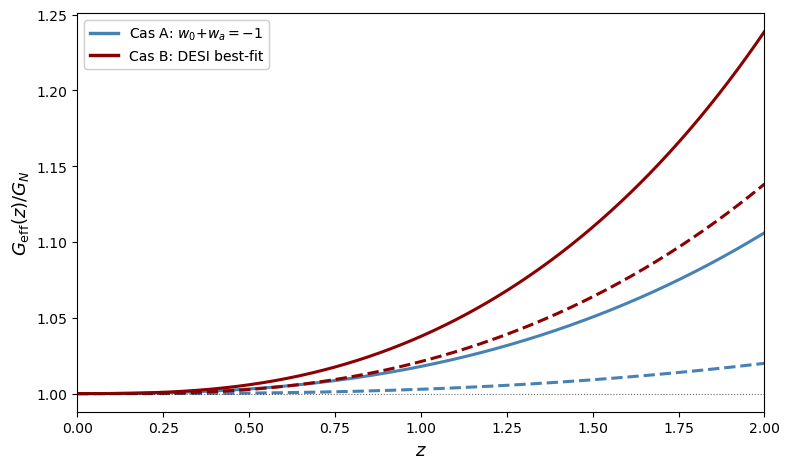

In [10]:
linestyles = ['-', '--']                       # sòlida = 1a tria, discontínua = 2a tria
rl_labels  = list(rho_Lambda_choices.keys())

fig, ax = plt.subplots(figsize=(8, 4.8))

for key, c in cases.items():
    for lbl, ls in zip(rl_labels, linestyles):
        z, Gn = results[key][lbl]
        ax.plot(z, Gn, color=c['color'], ls=ls, lw=2.2)

ax.axhline(1.0, color='k', lw=0.8, ls=':', alpha=0.6)
ax.set_xlabel(r'$z$', fontsize=13)
ax.set_ylabel(r'$G_{\rm eff}(z)/G_N$', fontsize=13)
ax.set_xlim(0, 2)

# Llegenda doble: color = cas ; estil = tria de rho_Lambda
color_handles = [Line2D([0],[0], color=c['color'], lw=2.4, label=c['label'])
                 for c in cases.values()]
style_handles = [Line2D([0],[0], color='k', lw=2.0, ls=ls, label=lbl)
                 for ls, lbl in zip(linestyles, rl_labels)]

leg1 = ax.legend(handles=color_handles, fontsize=10, loc='upper left')
                 #title='Color: cas CPL', framealpha=0.95)
ax.add_artist(leg1)
#ax.legend(handles=style_handles, fontsize=9, loc='lower right',
          #title=r'Estil: tria de $\rho_\Lambda$', framealpha=0.95)

plt.tight_layout()
plt.savefig('fig_Geff_cpl_dos_rhoLambda.pdf', dpi=150, bbox_inches='tight')
plt.show()